In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [5]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [4]:
! pip install --user -v CLUEstering


Using pip 24.0 from /usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pip (python 3.11)
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 8.5 MB/s eta 0:00:00m eta 0:00:010:00:01
  Running command pip subprocess to install build dependencies
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 954.3 kB/s eta 0:00:02
     ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 1.1 MB/s eta 0:00:01
     ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 0.5/1.1 MB 2.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━

In [6]:
import CLUEstering

In [7]:
from primary.clue import run_clue_hybrid
import torch
from primary.calibration import CALIBRATION
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv4
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles_hard_scatter=particles.lazy().with_columns(
    # 1. Find the INDICES strictly inside list.eval()
    # (pl.element() == 1) creates a boolean mask
    # .arg_true() converts that mask to indices
    _indices = pl.col("vertex_primary").list.eval(
        (pl.element() == 1).arg_true()
    )
).with_columns(
    # 2. Use those indices to pick elements from all other list columns
    pl.exclude("event_id", "_indices")
      .list.gather(pl.col("_indices"))
).drop("_indices").sort("event_id")
particles_hard_scatter = add_orphan_mask(particles_hard_scatter)
particles_hard_scatter = add_created_inside_calo_mask(particles_hard_scatter)
particles_hard_scatter = add_particle_have_track_mask(particles_hard_scatter, tracks)
particles_hard_scatter = add_eta_and_phi_and_pt(particles_hard_scatter)
particles_hard_scatter = get_particles_id_parent_of_inside_calo_particles_maskv3(particles_hard_scatter, calo_hits)
particles_hard_scatter = set_target_particles_maskv4(particles_hard_scatter, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)
event_id = 1000
calo = calo_hits.filter(pl.col('event_id')<= event_id)
# create mappings between calo hits particle id and their target particle ids
from primary.preprocessing import backtrack_to_target
calo_deps_particles = (
    calo.lazy()
    .select('contrib_particle_ids', 'event_id')
    .explode('contrib_particle_ids')
    .explode('contrib_particle_ids')
    .rename({'contrib_particle_ids': 'particle_id'})
    .unique()
)
target_particles = (
    particles_hard_scatter.lazy()
    .select('event_id', 'particle_id', 'is_target_particle', 'vertex_primary')
    .explode('particle_id','is_target_particle','vertex_primary')
    .filter(pl.col('is_target_particle') & (pl.col('event_id') <= event_id) & (pl.col('vertex_primary') == 1))
)


Computing parent existence mask...


/storage/agrp/barakma/PileupODD/primary/preprocessing.py:194: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "is_parent_missing" in df.columns:


Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 398524 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 6 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


In [11]:
calo_deps_mappings = backtrack_to_target(particles_hard_scatter, calo_deps_particles, target_particles)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [66]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from primary.calibration import CALIBRATION
from primary.clustering import execute, metric_eval

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 1000
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)

# Process Data: Explode -> Calibrate -> Group Back -> Pad
# This preserves the (Batch, Points) structure
data_processed = (
    calo.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')* 1000).alias('energy'))
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('x'), pl.col('y'), pl.col('z'), pl.col('energy'), pl.col('detector')
    ])
    .sort('event_id')
    .collect()
)

points_list = []
features_list = []

# Iterate and convert to Tensors
for row in data_processed.iter_rows(named=True):
    # Shape: (N_hits, 4) - x, y, z, energy
    # instead of energy, add ones as features for now
    ones = np.ones_like(row['x'])
    #p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    points_list.append(torch.tensor(p, dtype=torch.float32))
    

In [63]:

import CLUEstering as clue
#'dc': 105.29947637865176, 'dm': 207.87708279592312, 'rhoc': 0.41209239491050614, 'max_neighbors': 300
#dc - 45.97769115408347, 'dm': 70.16613717473524, 'rhoc': 0.17722605917818973
#clusterer = clue.clusterer(dc=45.977, rhoc=177, dm=70.166)
clusterer = clue.clusterer(dc=80.977, rhoc=80, dm=88.166, ppbin=16)



In [64]:
num_clusters_list = []
for i, points in enumerate(points_list):
    clusterer.read_data(points_list[i].T.numpy())
    clusterer.run_clue(backend='gpu cuda', verbose=True, block_size=1024)
    num_clusters_list.append(clusterer.n_clusters)

CLUE executed in 445.590301 ms
Number of clusters found: 3331
CLUE executed in 450.917007 ms
Number of clusters found: 3284
CLUE executed in 422.601781 ms
Number of clusters found: 3387
CLUE executed in 482.446306 ms
Number of clusters found: 3535
CLUE executed in 710.909792 ms
Number of clusters found: 3698
CLUE executed in 952.027087 ms
Number of clusters found: 3791
CLUE executed in 791.533898 ms
Number of clusters found: 3773
CLUE executed in 934.42427 ms
Number of clusters found: 3918
CLUE executed in 488.762403 ms
Number of clusters found: 3493
CLUE executed in 628.495064 ms
Number of clusters found: 3667
CLUE executed in 726.516788 ms
Number of clusters found: 3677
CLUE executed in 575.974345 ms
Number of clusters found: 3475
CLUE executed in 435.678794 ms
Number of clusters found: 3393
CLUE executed in 598.616255 ms
Number of clusters found: 3666
CLUE executed in 811.090567 ms
Number of clusters found: 3914
CLUE executed in 740.05429 ms
Number of clusters found: 3823
CLUE execu

In [39]:
import numpy as np
import polars as pl
from primary.calibration import CALIBRATION
import CLUEstering as clue

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 40
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)
# --------------------------------------------------------------------------------
# 2. DATA PROCESSING (Vectorized)
# --------------------------------------------------------------------------------
# Filter and Explode early to create a flat table of all hits
data_flat = (
    calo.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns([
        (pl.col('total_energy') * pl.col('calib_factor') * 1000).alias('energy'),
        pl.col('x').cast(pl.Float32),
        pl.col('y').cast(pl.Float32),
        pl.col('z').cast(pl.Float32)
    ])
    .select(['event_id', 'x', 'y', 'z', 'energy'])
    .sort('event_id')
    .collect()
)

# Prepare Numpy splits (same as previous optimization)
event_counts = data_flat.group_by('event_id', maintain_order=True).count()['count'].to_numpy()
all_points = data_flat.select(['x', 'y', 'z', 'energy']).to_numpy().astype(np.float32)
split_indices = np.cumsum(event_counts)[:-1]
points_list = np.split(all_points, split_indices)

# --------------------------------------------------------------------------------
# 3. CLUSTERING & CENTROID MAPPING
# --------------------------------------------------------------------------------

clusterer = clue.clusterer(dc=100.977, rhoc=50, dm=120.166, ppbin=16)

# Lists to store results for all events
res_cluster_ids = []
res_cx = []
res_cy = []
res_cz = []

for points in points_list:
    # 1. Run CLUE
    clusterer.read_data(points.T)
    clusterer.run_clue(backend='gpu cuda', verbose=False, block_size=1024)
    
    # 2. Extract IDs and Centroids
    # shape: (N_hits,)
    c_ids = clusterer.cluster_ids 
    # shape: (N_clusters, 4) - typically [x, y, z, energy]
    centroids = clusterer.cluster_centroids() 
    
    # 3. Vectorized Centroid Mapping (Replaces the slow 'for i' loop)
    # Initialize arrays with INF (noise value)
    n_points = len(c_ids)
    cx = np.full(n_points, float('inf'), dtype=np.float32)
    cy = np.full(n_points, float('inf'), dtype=np.float32)
    cz = np.full(n_points, float('inf'), dtype=np.float32)
    
    # Create a mask for valid clusters (assuming -1 is noise)
    valid_mask = c_ids != -1
    
    # If there are any valid clusters in this event
    if np.any(valid_mask):
        # Get the IDs of valid points
        valid_ids = c_ids[valid_mask]
        
        # Map centroids directly using Numpy fancy indexing
        # centroids array is indexed by the cluster ID
        cx[valid_mask] = centroids[valid_ids, 0]
        cy[valid_mask] = centroids[valid_ids, 1]
        cz[valid_mask] = centroids[valid_ids, 2]

    # 4. Append results
    res_cluster_ids.append(c_ids)
    res_cx.append(cx)
    res_cy.append(cy)
    res_cz.append(cz)

# --------------------------------------------------------------------------------
# 4. MERGE RESULTS BACK TO POLARS
# --------------------------------------------------------------------------------

# Concatenate all event results into long 1D arrays
final_ids = np.concatenate(res_cluster_ids)
final_cx = np.concatenate(res_cx)
final_cy = np.concatenate(res_cy)
final_cz = np.concatenate(res_cz)

# Add columns to the flat dataframe
data_clustered = data_flat.with_columns([
    pl.Series("cluster_id", final_ids),
    pl.Series("cluster_cx", final_cx),
    pl.Series("cluster_cy", final_cy),
    pl.Series("cluster_cz", final_cz)
])

# --------------------------------------------------------------------------------
# 5. (Optional) GROUP BACK TO LISTS
# If you need the original structure (one row per event_id, with lists inside)
# --------------------------------------------------------------------------------
aggrigated = (
    data_clustered
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('cluster_id'),
        pl.col('cluster_cx'),
        pl.col('cluster_cy'),
        pl.col('cluster_cz')
    ])
)
# add it to calo as columns
calo = calo.join(aggrigated, on='event_id', how='left')

/var/tmp/pbs.3726862.pbs/ipykernel_1986897/3738966406.py:32: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



[[  3]
 [436]
 [  2]
 ...
 [  4]
 [ 46]
 [  5]]
[[ 6]
 [10]
 [ 2]
 ...
 [26]
 [31]
 [ 1]]
[[  3]
 [  6]
 [  3]
 ...
 [  2]
 [  2]
 [398]]
[[  1]
 [ 73]
 [332]
 ...
 [223]
 [  1]
 [ 13]]
[[  1]
 [ 32]
 [  9]
 ...
 [  4]
 [  1]
 [552]]
[[  7]
 [ 92]
 [  3]
 ...
 [  2]
 [501]
 [  1]]
[[175]
 [328]
 [  1]
 ...
 [  9]
 [  2]
 [472]]
[[   6]
 [   5]
 [1278]
 ...
 [   1]
 [   1]
 [  11]]
[[552]
 [  3]
 [ 44]
 ...
 [  1]
 [273]
 [397]]
[[816]
 [  1]
 [313]
 ...
 [  4]
 [  4]
 [  1]]
[[    3]
 [    2]
 [    2]
 ...
 [    1]
 [29607]
 [  131]]
[[  1]
 [122]
 [  5]
 ...
 [  6]
 [ 26]
 [  1]]
[[854]
 [ 68]
 [ 60]
 ...
 [291]
 [ 87]
 [114]]
[[ 20]
 [237]
 [ 28]
 ...
 [  2]
 [277]
 [ 55]]
[[526]
 [  2]
 [  2]
 ...
 [  2]
 [ 27]
 [667]]
[[    4]
 [    3]
 [    8]
 ...
 [  120]
 [   21]
 [18057]]
[[  3]
 [  2]
 [100]
 ...
 [  1]
 [  1]
 [  2]]
[[464]
 [164]
 [  5]
 ...
 [  1]
 [  3]
 [  4]]
[[  5]
 [ 25]
 [146]
 ...
 [275]
 [  5]
 [545]]
[[  2]
 [  2]
 [534]
 ...
 [  6]
 [265]
 [  3]]
[[145]
 [ 24]
 [

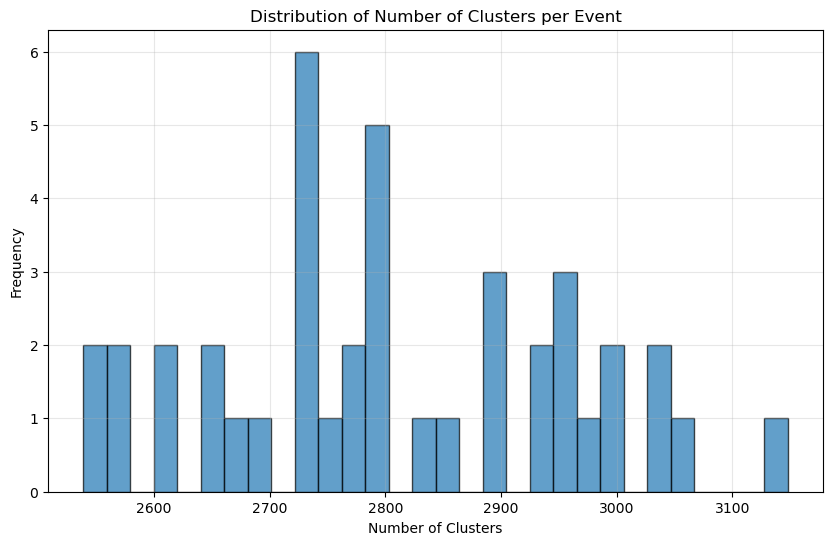

In [40]:
# ...existing code...
num_clusters_df = (calo
    .select('cluster_id', 'event_id')
    .with_columns(
        pl.col('cluster_id')
        .list.unique()
        .list.eval(pl.element().filter(pl.element() != -1))
        .list.len()
        .alias('num_clusters')
    )
    .drop('cluster_id')
)

plt.figure(figsize=(10, 6))
plt.hist(num_clusters_df['num_clusters'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Clusters')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Clusters per Event')
plt.grid(True, alpha=0.3)
plt.show()

event_id,num_clusters
u32,u32
0,2177
1,2198
2,2166
3,2307
4,2408
…,…
46,2327
47,2332
48,2337


In [14]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)

FigureWidget({
    'data': [{'customdata': array([[1888, 0.24384852731600404, 1.0,
                                    '<b>p</b> (PDG:2212) ID:185321: <b>0.2438 GeV</b>'],
                                   [52, 0.217799187079072, 1.0,
                                    '<b>π+</b> (PDG:211) ID:299: <b>0.2178 GeV</b>'],
                                   [27, 0.21648891357472166, 1.0,
                                    '<b>π-</b> (PDG:-211) ID:187810: <b>0.2165 GeV</b>'],
                                   ...,
                                   [714, 0.7661244095535948, 0.9410854289694673,
                                    '<b>π+</b> (PDG:211) ID:184291: <b>0.4333 GeV</b><br><b>p</b> (PDG:2212) ID:182444: <b>0.2176 GeV</b><br><b>π+</b> (PDG:211) ID:149269: <b>0.0451 GeV</b><br><b>p</b> (PDG:2212) ID:182415: <b>0.0304 GeV</b><br><b>e-</b> (PDG:11) ID:184292: <b>0.0255 GeV</b>'],
                                   [1377, 0.2183533401868772, 0.8784730382204283,
                       

In [49]:
calo

event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times,cluster_id,cluster_cx,cluster_cy,cluster_cz
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]],"array[i32, 669672]","array[f64, 6665]","array[f64, 6665]","array[f64, 6665]"
0,"[9, 10, … 12]","[0.000816, 0.000229, … 0.001104]","[202.36615, 142.800003, … -426.024139]","[296.12851, -1333.199951, … -383.597717]","[-3308.449951, 1071.0, … -3698.5]","[[140074], [176808], … [101665]]","[[0.000816], [0.000229], … [0.001104]]","[[11.255494], [6.272169], … [12.511644]]","[831, 731, … 4102]","[-398.742391, 490.346629, … 999.584901]","[-1095.918701, 1161.589925, … 69.563266]","[-3306.766602, -2599.300049, … -3251.034061]"


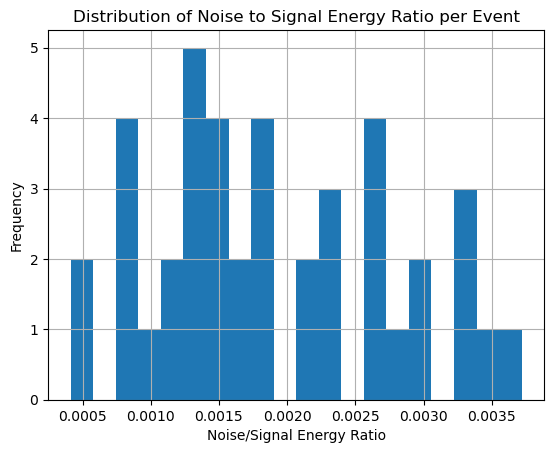

event_id,signal_energy,noise_energy,noise_signal_ratio
u32,f64,f64,f64
4,851.637775,1.110257,0.001304
5,898.098161,2.396722,0.002669
6,530.32394,1.210267,0.002282
3,651.764835,1.770755,0.002717
11,541.588166,0.48367,0.000893
…,…,…,…
32,1400.901644,2.47444,0.001766
33,805.167997,1.470399,0.001826
37,1080.300031,2.539847,0.002351


In [41]:
# ...existing code...
# Prepare base query with common operations
base_query = (
    calo.lazy()
    .select('contrib_particle_ids', 'contrib_energies', 'event_id', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies')
    .rename({'contrib_particle_ids':'particle_id', 'contrib_energies':'energy_contribution'})
    # Calibrate energy contributions
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('energy_contribution') * pl.col('calib_factor')).alias('energy_contribution'))
    .join(
        particles.lazy()
        .select('event_id', 'particle_id','vertex_primary')
        .explode('particle_id','vertex_primary'), on=['event_id','particle_id'], how='inner'
    )
    .join(calo_deps_mappings.lazy(),
            left_on=['event_id','particle_id'], right_on=['event_id','src_particle_id'], how='inner'
        )
    .filter(pl.col('target_particle_id').is_not_null())
    .with_columns(pl.when(pl.col('vertex_primary') == 1).then(1).otherwise(0).alias('hard_scatter'))
    .filter(pl.col('hard_scatter') == 1)
)

# Calculate Signal Energy (cluster_id != -1)
signal_df = (
    base_query
    .filter(pl.col('cluster_id') != -1)
    .group_by('event_id')
    .agg(pl.col('energy_contribution').sum().alias('signal_energy'))
)

# Calculate Noise Energy (cluster_id == -1)
noise_df = (
    base_query
    .filter(pl.col('cluster_id') == -1)
    .group_by('event_id')
    .agg(pl.col('energy_contribution').sum().alias('noise_energy'))
)

# Join and ratio
final_df = (
    signal_df.join(noise_df, on='event_id', how='inner')
    .fill_null(0)
    .with_columns((pl.col('noise_energy') / (pl.col('signal_energy') + 1e-9)).alias('noise_signal_ratio'))
    .collect()
)
plt.hist(final_df['noise_signal_ratio'], bins=20)
plt.xlabel('Noise/Signal Energy Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Noise to Signal Energy Ratio per Event')
plt.grid(True)
plt.show()  
final_df

/var/tmp/pbs.3726862.pbs/ipykernel_1986897/4183482699.py:9: DeprecationWarning:

the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.



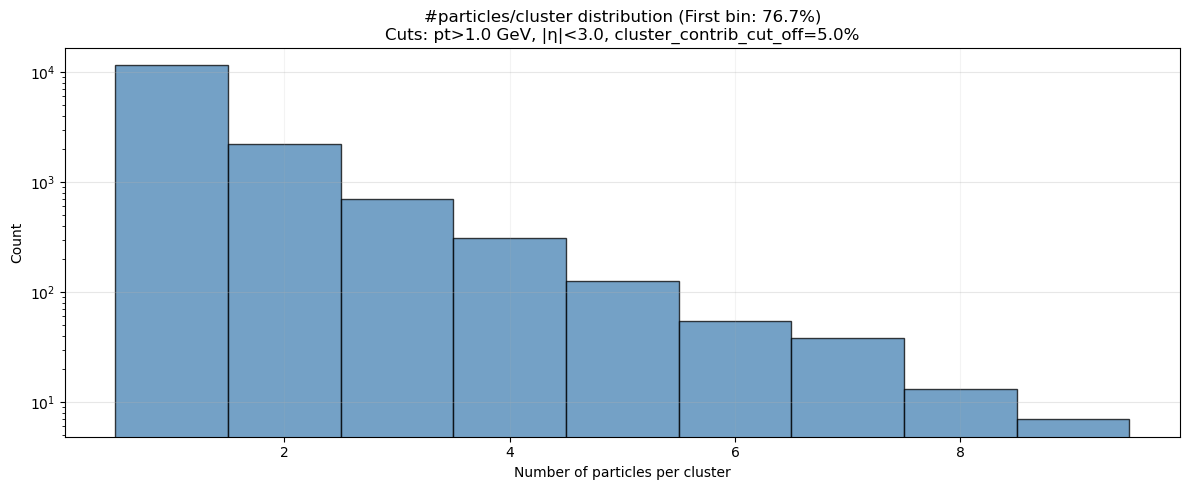

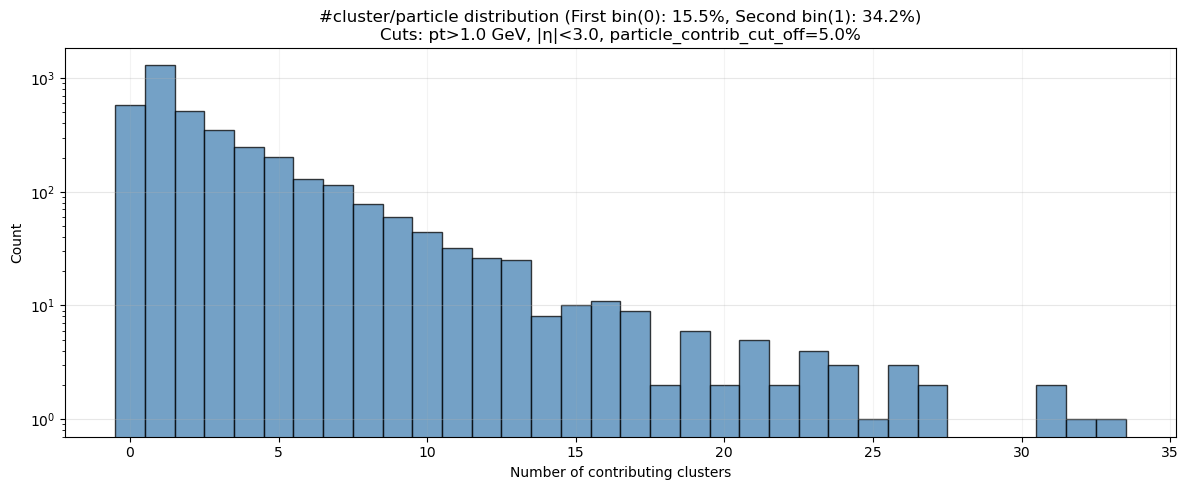

In [42]:
from primary.preprocessing import number_of_particles_per_cluster,number_of_clusters_per_particle
from primary.plot import plot_num_contributing_clusters,plot_num_contributing_ancestors

from primary.preprocessing import backtrack_to_target
target = (particles_hard_scatter.lazy()
        .select(['event_id','particle_id', 'is_target_particle'])
          .explode(['is_target_particle', 'particle_id'])
          .filter(pl.col('is_target_particle'))
          ).collect(streaming=True)
base  =(
        calo.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    )
result = calo_deps_mappings

result = result.filter(pl.col('event_id').is_in(calo['event_id'].unique().implode()))
particles_to_pass = particles_hard_scatter.filter(pl.col('event_id').is_in(calo['event_id'].unique().implode()))
p = plot_num_contributing_ancestors(calo, result,particles=particles_to_pass, cut_off_percent=0.05, pt_cut=1.0, eta_cut=3.0)
c = plot_num_contributing_clusters(calo, result,particles=particles_to_pass,
                                     cut_off_percent=0.05, pt_cut=1.0, eta_cut=3.0)

In [38]:
c

event_id,particle_id,is_target_particle,pt,eta,ultimate_ancestor_id,num_contributing_clusters,max_ancestor_energy_deps_in_cluster
u32,u64,bool,f32,f32,i64,u32,f64
24,256,true,17.615175,2.981144,256,15,42.652035
89,866,true,1.08345,1.655336,866,2,0.341898
41,732,true,2.013069,1.78266,732,2,6.602604
52,574,true,3.662486,0.595397,574,2,3.666778
55,215,true,1.166736,0.636541,215,4,0.458694
…,…,…,…,…,…,…,…
20,184532,true,1.105481,2.077085,184532,0,0.0
85,200,true,1.505265,-2.343778,200,0,0.0
85,533,true,1.050637,-1.328502,533,0,0.0
